In [35]:
import warnings, json, os, time
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import gaussian_kde
from config import (
    DATA_PATH, SAMPLE_FRAC, TARGET, FEATURE_COLS,
    TEST_SIZE, RANDOM_STATE
)
from data_loader import load_data
from data_preprocessor import make_target, prepare_xy
from feature_engineering import extract_coords_features, engineer_features
from models_build import build_models
from models_train import cross_validate_model
from models_stacking import build_stacking_meta
from metrics import evaluate, rmsle

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

warnings.filterwarnings("ignore")

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3250',
    'axes.labelcolor':  '#c9d1d9',
    'axes.titlecolor':  '#ffffff',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#2e3250',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
PALETTE = ['#58a6ff', '#f78166', '#3fb950', '#d2a8ff', '#ffa657', '#79c0ff']

print('Импорты выполнены')

Импорты выполнены


In [ ]:
from pathlib import Path

# ── Данные ───────────────────────────────────────────────────────────────────
DATA_PATH   = Path("train.csv")
SAMPLE_FRAC = 0.5
TARGET      = "trip_time"

# ── Валидация ─────────────────────────────────────────────────────────────────
N_CV_FOLDS  = 3
TEST_SIZE   = 0.2
RANDOM_STATE = 42

# ── Признаки ─────────────────────────────────────────────────────────────────
FEATURE_COLS = [
    "hour", "dow", "month", "is_weekend", "is_rush",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "call_type_enc", "day_type_enc", "taxi_freq",
    "start_lon", "start_lat", "end_lon", "end_lat",
    "direct_dist_km", "total_dist_km", "straightness",
    "mean_lon", "mean_lat",
    "log_direct_dist", "log_total_dist", "bbox_area",
]

# ── Модели ────────────────────────────────────────────────────────────────────
RF_PARAMS = {
    "n_estimators":   300,
    "max_depth":      20,
    "min_samples_leaf": 10,
    "max_features":   0.5,
    "n_jobs":         -1,
    "random_state":   RANDOM_STATE,
}

LGBM_PARAMS = {
    "n_estimators":     1000,
    "learning_rate":    0.03,
    "num_leaves":       127,
    "max_depth":        -1,
    "min_child_samples": 20,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq":     5,
    "reg_alpha":        0.1,
    "reg_lambda":       0.1,
    "n_jobs":           -1,
    "random_state":     RANDOM_STATE,
    "verbose":          -1,
}

XGB_PARAMS = {
    "n_estimators":       1000,
    "learning_rate":      0.03,
    "max_depth":          8,
    "subsample":          0.8,
    "colsample_bytree":   0.8,
    "min_child_weight":   5,
    "reg_alpha":          0.1,
    "reg_lambda":         1.0,
    "n_jobs":             -1,
    "random_state":       RANDOM_STATE,
    "verbosity":          0,
    "eval_metric":        "rmse",
}

CB_PARAMS = {
    "iterations":          1000,
    "learning_rate":       0.03,
    "depth":               8,
    "l2_leaf_reg":         3,
    "random_seed":         RANDOM_STATE,
    "verbose":             0,
}

# ── Стекинг ───────────────────────────────────────────────────────────────────
META_MODEL_ALPHA = 1.0   # Ridge alpha

In [ ]:
# data_loader.py

import os
import pandas as pd
from pathlib import Path

def load_data(path: Path, sample_frac: float = 1.0) -> pd.DataFrame:
    if not os.path.exists(path):
        print(f'Файл не найден. Путь {path} неверный.')
        return None
    try:
        print('Файл успешно загружен')
        df = pd.read_csv(path)
        return df.sample(frac=sample_frac, random_state=42) if sample_frac < 1.0 else df
    except Exception as e:
        print(f'Возникла ошибка {e} при загрузке файла.')
        return None

In [ ]:
# data_preprocessor.py

import json
import pandas as pd
import numpy as np
from config import TARGET, FEATURE_COLS


def parse_polyline(poly_str: str):
    """Return list of [lon, lat] coordinates."""
    try:
        coords = json.loads(poly_str)
        return coords if isinstance(coords, list) else []
    except Exception:
        return []


def make_target(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute trip_time from POLYLINE length.
    Each GPS point is recorded every 15 seconds.
    """
    print("[2/6] Computing target (trip_time) …")
    df = df.copy()
    df["coords"]    = df["POLYLINE"].apply(parse_polyline)
    df["n_points"]  = df["coords"].apply(len)
    df[TARGET]      = (df["n_points"] - 1) * 15   # seconds
    # Remove empty / missing trips
    df = df[df["n_points"] > 1].reset_index(drop=True)
    # Remove extreme outliers (>2h trip)
    q_high = df[TARGET].quantile(0.9995)
    df = df[df[TARGET] <= q_high].reset_index(drop=True)
    print(f"      Rows after filtering: {len(df):,} | "
          f"mean trip_time = {df[TARGET].mean():.0f}s")
    return df


def prepare_xy(df: pd.DataFrame):
    df = df.dropna(subset=FEATURE_COLS + [TARGET])
    X = df[FEATURE_COLS].astype(float)
    y = np.log1p(df[TARGET].astype(float))   # log-transform target
    return X, y

In [ ]:
# feature_engineering.py
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder


def haversine(lon1, lat1, lon2, lat2):
    """Great-circle distance in km."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi  = np.radians(lat2 - lat1)
    dlam  = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2*R*np.arcsin(np.sqrt(a))


def extract_coords_features(row):
    coords = row["coords"]
    n = len(coords)
    if n < 2:
        return pd.Series({
            "start_lon": np.nan, "start_lat": np.nan,
            "end_lon":   np.nan, "end_lat":   np.nan,
            "direct_dist_km": np.nan,
            "total_dist_km":  np.nan,
            "straightness":   np.nan,
            "mean_lon": np.nan, "mean_lat": np.nan,
        })
    lons = [c[0] for c in coords]
    lats = [c[1] for c in coords]

    # direct distance
    direct = haversine(lons[0], lats[0], lons[-1], lats[-1])

    # cumulative distance along the route
    seg_dists = [
        haversine(lons[i], lats[i], lons[i+1], lats[i+1])
        for i in range(n-1)
    ]
    total = sum(seg_dists)

    straightness = direct / total if total > 0 else 1.0

    return pd.Series({
        "start_lon":      lons[0],
        "start_lat":      lats[0],
        "end_lon":        lons[-1],
        "end_lat":        lats[-1],
        "direct_dist_km": direct,
        "total_dist_km":  total,
        "straightness":   straightness,
        "mean_lon":       np.mean(lons),
        "mean_lat":       np.mean(lats),
    })


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    print("[3/6] Engineering features …")
    df = df.copy()

    # ── Temporal features ────────────────────────────────────────────────────
    ts = pd.to_datetime(df["TIMESTAMP"], unit="s", utc=True)
    df["hour"]        = ts.dt.hour
    df["dow"]         = ts.dt.dayofweek          # 0=Mon … 6=Sun
    df["month"]       = ts.dt.month
    df["is_weekend"]  = (df["dow"] >= 5).astype(int)
    df["is_rush"]     = df["hour"].isin([7,8,9,17,18,19]).astype(int)
    df["hour_sin"]    = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"]    = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"]     = np.sin(2 * np.pi * df["dow"]  / 7)
    df["dow_cos"]     = np.cos(2 * np.pi * df["dow"]  / 7)

    # ── CALL_TYPE → numeric ──────────────────────────────────────────────────
    df["call_type_enc"] = LabelEncoder().fit_transform(
        df["CALL_TYPE"].fillna("UNKNOWN")
    )

    # ── DAY_TYPE → numeric ───────────────────────────────────────────────────
    df["day_type_enc"] = LabelEncoder().fit_transform(
        df["DAY_TYPE"].fillna("A")
    )

    # ── TAXI_ID frequency encoding ───────────────────────────────────────────
    freq = df["TAXI_ID"].value_counts() / len(df)
    df["taxi_freq"] = df["TAXI_ID"].map(freq).fillna(0)

    # ── Coordinate / route features ──────────────────────────────────────────
    coord_feats = df.apply(extract_coords_features, axis=1)
    df = pd.concat([df, coord_feats], axis=1)

    # ── Log-distance (robust to 0) ───────────────────────────────────────────
    df["log_direct_dist"] = np.log1p(df["direct_dist_km"].clip(0))
    df["log_total_dist"]  = np.log1p(df["total_dist_km"].clip(0))

    # ── Speed proxy (dist per point = dist per 15s) ──────────────────────────
    df["speed_proxy"] = df["total_dist_km"] / (df["n_points"] * 15 / 3600 + 1e-9)

    # ── Bounding box ─────────────────────────────────────────────────────────
    df["bbox_area"] = (
        (df["end_lon"] - df["start_lon"]).abs() *
        (df["end_lat"] - df["start_lat"]).abs()
    )

    print(f"      Feature count: {df.shape[1]}")
    return df

In [ ]:
# models_build.py

import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from config import LGBM_PARAMS, XGB_PARAMS, CB_PARAMS, RF_PARAMS


def build_models():
    return {
        "Dummy":          DummyRegressor(strategy="mean"),
        "RandomForest":   RandomForestRegressor(**RF_PARAMS),
        "LightGBM":       lgb.LGBMRegressor(**LGBM_PARAMS),
        "XGBoost":        xgb.XGBRegressor(**XGB_PARAMS),
        "CatBoost":       cb.CatBoostRegressor(**CB_PARAMS),
    }

In [ ]:
# models_train.py

import numpy as np
from sklearn.model_selection import KFold
from config import N_CV_FOLDS, RANDOM_STATE


def cross_validate_model(name, model, X, y):
    kf  = KFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(y))

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X), 1):
        print(f"    fold {fold}/{N_CV_FOLDS}", end="\r")
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model.fit(X_tr, y_tr)
        oof[val_idx] = model.predict(X_val)

    return oof

In [ ]:
# models_stacking.py

import numpy as np
from sklearn.linear_model import Ridge
from config import META_MODEL_ALPHA

SKIP_MODELS = {"Dummy"}

def build_stacking_meta(oof_dict: dict, y_train, test_preds_dict: dict):
    """
    oof_dict        — {model_name: oof_predictions} на train
    test_preds_dict — {model_name: predictions} на test
    Мета-модель: Ridge регрессия поверх OOF
    """
    # Убираем Dummy
    oof_filtered  = {k: v for k, v in oof_dict.items()  if k not in SKIP_MODELS}
    test_filtered = {k: v for k, v in test_preds_dict.items() if k not in SKIP_MODELS}

    X_meta_train = np.column_stack(list(oof_filtered.values()))
    X_meta_test  = np.column_stack(list(test_filtered.values()))

    meta_model = Ridge(alpha=META_MODEL_ALPHA)
    meta_model.fit(X_meta_train, y_train)

    y_pred_stack = meta_model.predict(X_meta_test)
    return y_pred_stack, meta_model

In [ ]:
# metrics.py

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def rmsle(y_true_log, y_pred_log):
    """RMSLE on log-transformed target."""
    return np.sqrt(mean_squared_error(y_true_log, y_pred_log))


def evaluate(name, y_true_log, y_pred_log):
    rmsl = rmsle(y_true_log, y_pred_log)
    mae  = mean_absolute_error(np.expm1(y_true_log), np.expm1(y_pred_log))
    r2   = r2_score(y_true_log, y_pred_log)
    print(f"  [{name}]  RMSLE={rmsl:.4f}  MAE={mae:.1f}s  R²={r2:.4f}")
    return {"model": name, "RMSLE": rmsl, "MAE_sec": mae, "R2": r2}

In [ ]:
# 1. Загрузка данных

df_raw = load_data(DATA_PATH, SAMPLE_FRAC)
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Файл успешно загружен
Shape: (855335, 9)


,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
1414161,1399190091620000213,B,NaN,10.0,20000213,1399190091,A,False,"[[-8.607096,41.150286],[-8.607123,41.150214],[..."
1397309,1398928351620000092,C,NaN,NaN,20000092,1398928351,A,False,"[[-8.638533,41.159133],[-8.63856,41.15907],[-8..."
560966,1383056851620000263,B,NaN,9.0,20000263,1383056851,A,False,"[[-8.60652,41.144562],[-8.606934,41.144724],[-..."


In [3]:
# Типы и пропуски
info = pd.DataFrame({
    'dtype':   df_raw.dtypes,
    'nulls':   df_raw.isnull().sum(),
    'null_%':  (df_raw.isnull().mean() * 100).round(2),
    'nunique': df_raw.nunique(),
})
info

,dtype,nulls,null_%,nunique
TRIP_ID,int64,0,0.00,855316
CALL_TYPE,str,0,0.00,3
ORIGIN_CALL,float64,672779,78.66,39816
ORIGIN_STAND,float64,452439,52.90,63
TAXI_ID,int64,0,0.00,445
TIMESTAMP,int64,0,0.00,841308
DAY_TYPE,str,0,0.00,1
MISSING_DATA,bool,0,0.00,2
POLYLINE,str,0,0.00,852105


In [4]:
# 2. Целевая переменная

df = make_target(df_raw)
print(f'Строк после фильтрации: {len(df):,}')
print(f'Средняя длина поездки:  {df[TARGET].mean():.0f} сек ({df[TARGET].mean()/60:.1f} мин)')

[2/6] Computing target (trip_time) …
      Rows after filtering: 836,647 | mean trip_time = 723s
Строк после фильтрации: 836,647
Средняя длина поездки:  723 сек (12.1 мин)


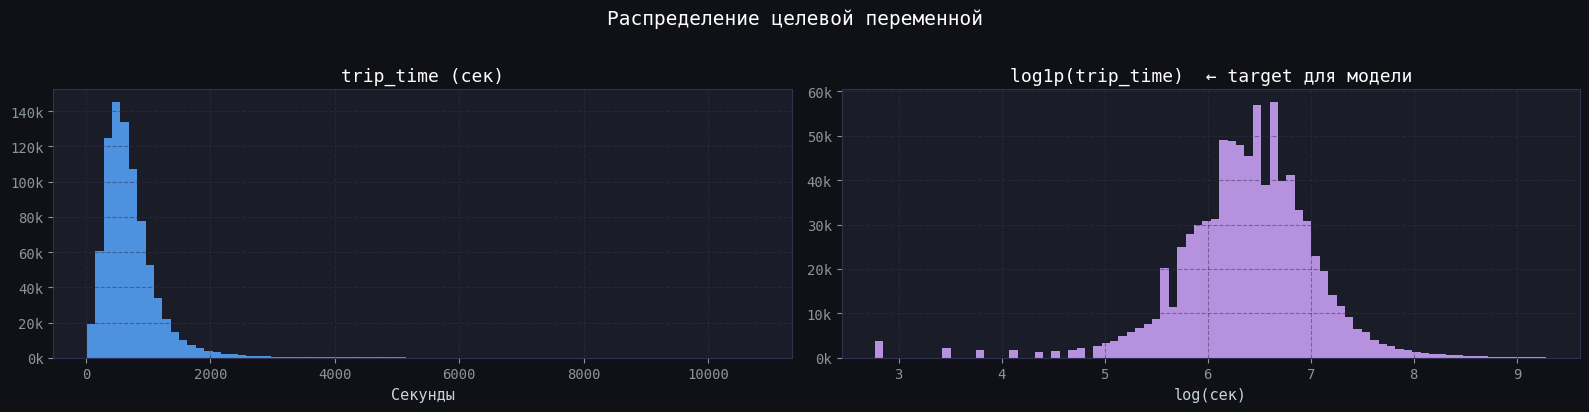

In [ ]:
# Визуализация: Распределение trip_time

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Распределение целевой переменной', fontsize=14, color='white', y=1.02)

axes[0].hist(df[TARGET], bins=80, color=PALETTE[0], alpha=0.85, edgecolor='none')
axes[0].set_title('trip_time (сек)')
axes[0].set_xlabel('Секунды')

axes[1].hist(np.log1p(df[TARGET]), bins=80, color=PALETTE[3], alpha=0.85, edgecolor='none')
axes[1].set_title('log1p(trip_time)  ← target для модели')
axes[1].set_xlabel('log(сек)')

for ax in axes:
    ax.set_facecolor('#1a1d27')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    ax.grid(True)

plt.tight_layout()
plt.show()

In [7]:
# 3. Feature Engineering

df = engineer_features(df)
print(f'Фичей: {df.shape[1]}')

[3/6] Engineering features …
      Feature count: 37
Фичей: 37


In [8]:
# Сохранение данных после предобработки

df.drop(columns=['coords']).to_parquet('df_features.parquet', index=False)
print('Сохранено: df_features.parquet')

Сохранено: df_features.parquet


In [3]:
# Загрузка данных
df = pd.read_parquet('df_features.parquet')

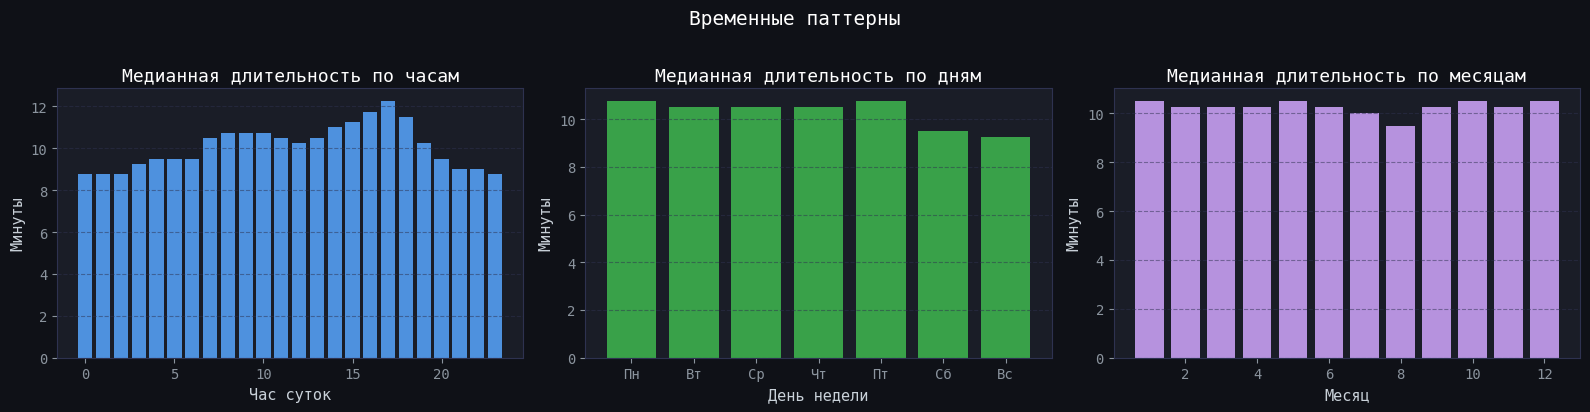

In [3]:
# Визуализация: Временные паттерны

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Временные паттерны', fontsize=14, color='white', y=1.02)

hour_med = df.groupby('hour')[TARGET].median() / 60
axes[0].bar(hour_med.index, hour_med.values, color=PALETTE[0], alpha=0.85)
axes[0].set_title('Медианная длительность по часам')
axes[0].set_xlabel('Час суток')
axes[0].set_ylabel('Минуты')

dow_labels = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']
dow_med = df.groupby('dow')[TARGET].median() / 60
axes[1].bar(dow_labels, dow_med.values, color=PALETTE[2], alpha=0.85)
axes[1].set_title('Медианная длительность по дням')
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Минуты')

month_med = df.groupby('month')[TARGET].median() / 60
axes[2].bar(month_med.index, month_med.values, color=PALETTE[3], alpha=0.85)
axes[2].set_title('Медианная длительность по месяцам')
axes[2].set_xlabel('Месяц')
axes[2].set_ylabel('Минуты')

for ax in axes:
    ax.set_facecolor('#1a1d27')
    ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

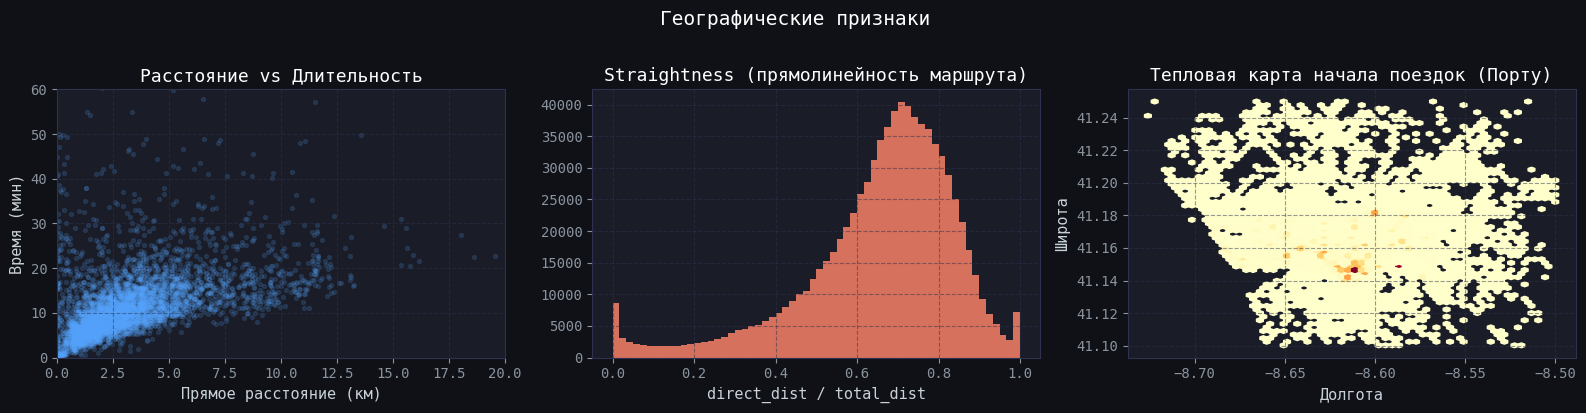

In [4]:
# Визуализация: Географические признаки

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Географические признаки', fontsize=14, color='white', y=1.02)

sample = df.dropna(subset=['direct_dist_km']).sample(min(5000, len(df)), random_state=42)
axes[0].scatter(sample['direct_dist_km'], sample[TARGET]/60,
                alpha=0.15, s=8, color=PALETTE[0])
axes[0].set_title('Расстояние vs Длительность')
axes[0].set_xlabel('Прямое расстояние (км)')
axes[0].set_ylabel('Время (мин)')
axes[0].set_xlim(0, 20)
axes[0].set_ylim(0, 60)

axes[1].hist(df['straightness'].dropna().clip(0, 1), bins=60,
             color=PALETTE[1], alpha=0.85, edgecolor='none')
axes[1].set_title('Straightness (прямолинейность маршрута)')
axes[1].set_xlabel('direct_dist / total_dist')

valid = df.dropna(subset=['start_lon','start_lat'])
valid = valid[(valid['start_lon'].between(-8.8, -8.5)) &
              (valid['start_lat'].between(41.1, 41.25))]
axes[2].hexbin(valid['start_lon'], valid['start_lat'],
               gridsize=60, cmap='YlOrRd', mincnt=1)
axes[2].set_title('Тепловая карта начала поездок (Порту)')
axes[2].set_xlabel('Долгота')
axes[2].set_ylabel('Широта')

for ax in axes:
    ax.set_facecolor('#1a1d27')
    ax.grid(True)

plt.tight_layout()
plt.show()


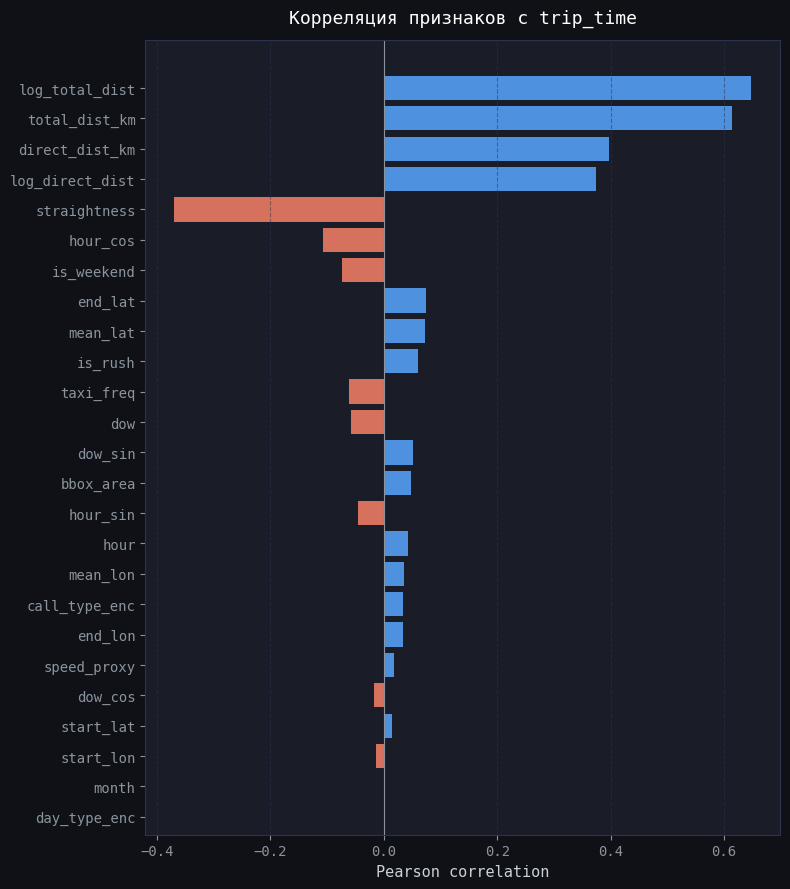

In [5]:
# Визуализация: Корреляции с target

corr_df = df[FEATURE_COLS + [TARGET]].dropna()
corr = corr_df.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
fig.patch.set_facecolor('#0f1117')
colors = [PALETTE[0] if v > 0 else PALETTE[1] for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, alpha=0.85)
ax.set_title('Корреляция признаков с trip_time', pad=12)
ax.set_xlabel('Pearson correlation')
ax.axvline(0, color='#8b949e', linewidth=0.8)
ax.grid(True, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [4]:
#  4. Подготовка данных

X, y = prepare_xy(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}  |  Features: {X.shape[1]}')

Train: 669,317  |  Test: 167,330  |  Features: 24


In [8]:
# 5. Обучение моделей

models         = build_models()
results        = []
oof_dict       = {}
test_pred_dict = {}

for name, model in models.items():
    print(f'\n {name}')
    t0 = time.time()

    oof = cross_validate_model(name, model, X_train, y_train)
    oof_dict[name] = oof
    results.append(evaluate(f'{name} CV-OOF', y_train, oof))

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_pred_dict[name] = y_pred
    results.append(evaluate(f'{name} TEST', y_test, y_pred))

    print(f'    время: {time.time()-t0:.0f}с')


 Dummy
  [Dummy CV-OOF]  RMSLE=0.6719  MAE=322.7s  R²=-0.0000
  [Dummy TEST]  RMSLE=0.6699  MAE=322.3s  R²=-0.0000
    время: 0с

 RandomForest
  [RandomForest CV-OOF]  RMSLE=0.2846  MAE=148.4s  R²=0.8206
  [RandomForest TEST]  RMSLE=0.2811  MAE=146.0s  R²=0.8239
    время: 1731с

 LightGBM
  [LightGBM CV-OOF]  RMSLE=0.2635  MAE=138.8s  R²=0.8462
  [LightGBM TEST]  RMSLE=0.2616  MAE=137.7s  R²=0.8475
    время: 232с

 XGBoost
  [XGBoost CV-OOF]  RMSLE=0.2652  MAE=138.7s  R²=0.8443
  [XGBoost TEST]  RMSLE=0.2632  MAE=137.5s  R²=0.8456
    время: 259с

 CatBoost
  [CatBoost CV-OOF]  RMSLE=0.2818  MAE=148.8s  R²=0.8241
  [CatBoost TEST]  RMSLE=0.2809  MAE=148.4s  R²=0.8242
    время: 348с


In [5]:
# 6. Стекинг

y_pred_stack, meta_model = build_stacking_meta(
    oof_dict, y_train, test_pred_dict
)
results.append(evaluate('Stacking TEST', y_test, y_pred_stack))

print('\nВеса мета-модели (Ridge):')
stacking_names = [k for k in oof_dict if k != 'Dummy']
for name, coef in zip(stacking_names, meta_model.coef_):
    print(f'  {name:15s}: {coef:.4f}')

  [Stacking TEST]  RMSLE=0.2588  MAE=135.7s  R²=0.8508

Веса мета-модели (Ridge):
  RandomForest   : 0.0261
  LightGBM       : 0.8348
  XGBoost        : 0.6169
  CatBoost       : -0.4742


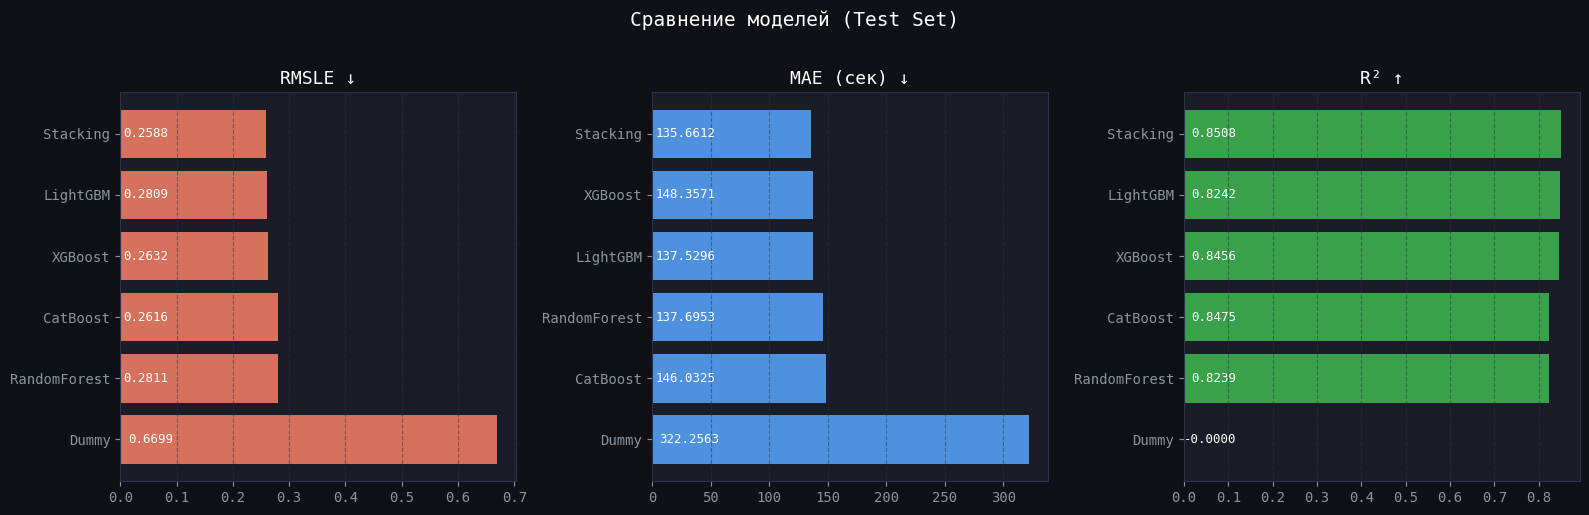


              model    RMSLE    MAE_sec        R2
       Dummy CV-OOF 0.671891 322.739323 -0.000003
         Dummy TEST 0.669878 322.256277 -0.000001
RandomForest CV-OOF 0.284599 148.362824  0.820581
  RandomForest TEST 0.281140 146.032535  0.823862
    LightGBM CV-OOF 0.263480 138.797840  0.846220
      LightGBM TEST 0.261587 137.695325  0.847510
     XGBoost CV-OOF 0.265161 138.703442  0.844252
       XGBoost TEST 0.263235 137.529563  0.845583
    CatBoost CV-OOF 0.281811 148.822256  0.824078
      CatBoost TEST 0.280856 148.357082  0.824217
      Stacking TEST 0.258790 135.661190  0.850753


In [8]:
# Визуализация: Сравнение моделей

summary = pd.DataFrame(results)
test_summary = summary[summary['model'].str.contains('TEST')].copy()
test_summary['model'] = test_summary['model'].str.replace(' TEST', '')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Сравнение моделей (Test Set)', fontsize=14, color='white', y=1.02)

for ax, metric, label, color, ascending in zip(
    axes,
    ['RMSLE', 'MAE_sec', 'R2'],
    ['RMSLE ↓', 'MAE (сек) ↓', 'R² ↑'],
    [PALETTE[1], PALETTE[0], PALETTE[2]],
    [False, False, True]
):
    sorted_df = test_summary.sort_values(metric, ascending=ascending)
    bars = ax.barh(sorted_df['model'], sorted_df[metric], color=color, alpha=0.85)
    ax.set_title(label)
    ax.grid(True, axis='x')
    ax.set_facecolor('#1a1d27')
    for bar, val in zip(bars, test_summary[metric]):
        ax.text(bar.get_width() * 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

print()
print(summary.to_string(index=False))

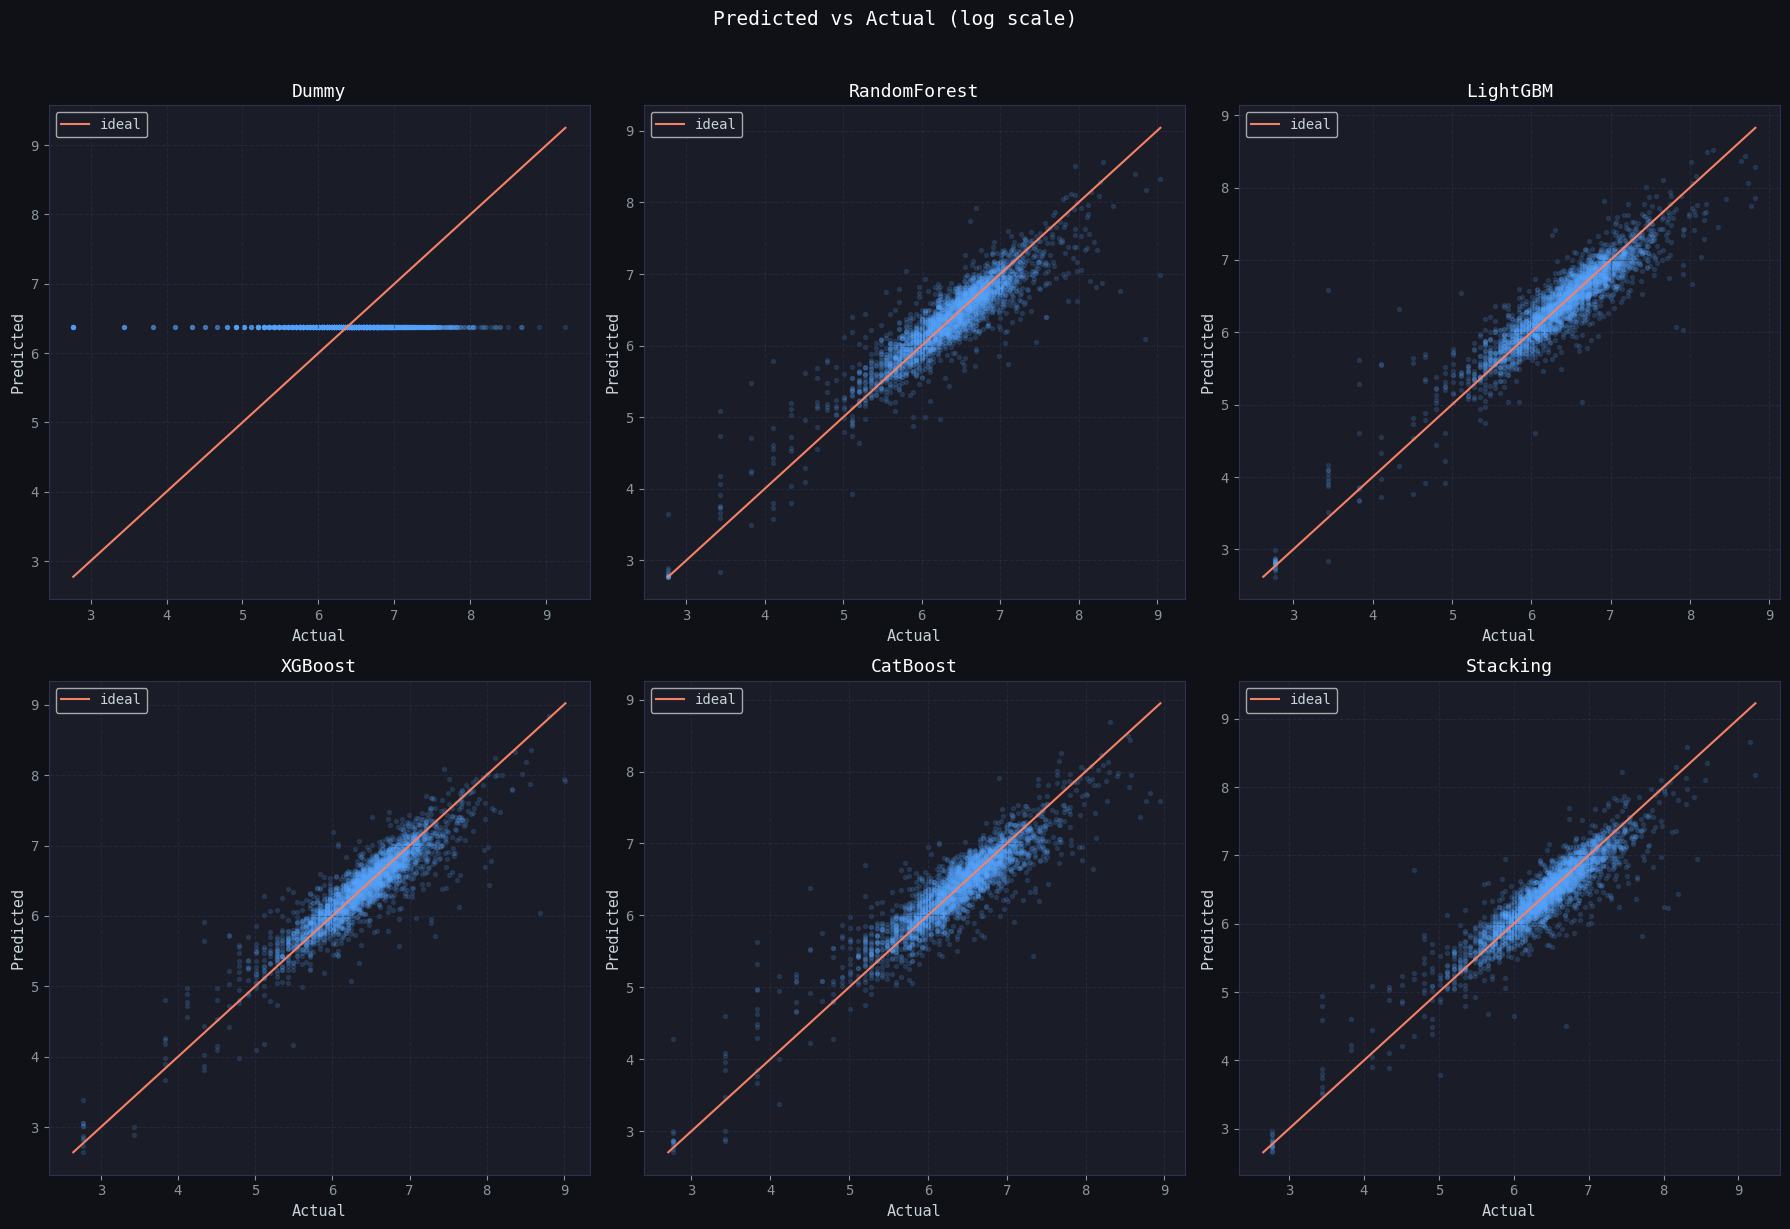

In [11]:
# Визуализация: Predicted vs Actual

plot_preds = {**test_pred_dict, 'Stacking': y_pred_stack}
names = list(plot_preds.keys())

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Predicted vs Actual (log scale)', fontsize=14, color='white', y=1.02)
axes = axes.flatten()

for i, (name, y_pred) in enumerate(plot_preds.items()):
    ax = axes[i]
    idx = np.random.choice(len(y_test), min(3000, len(y_test)), replace=False)
    yt, yp = np.array(y_test)[idx], y_pred[idx]
    ax.scatter(yt, yp, alpha=0.15, s=8, color=PALETTE[0])
    mn, mx = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    ax.plot([mn, mx], [mn, mx], color=PALETTE[1], linewidth=1.5, label='ideal')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.legend()
    ax.grid(True)
    ax.set_facecolor('#1a1d27')

plt.tight_layout()
plt.show()

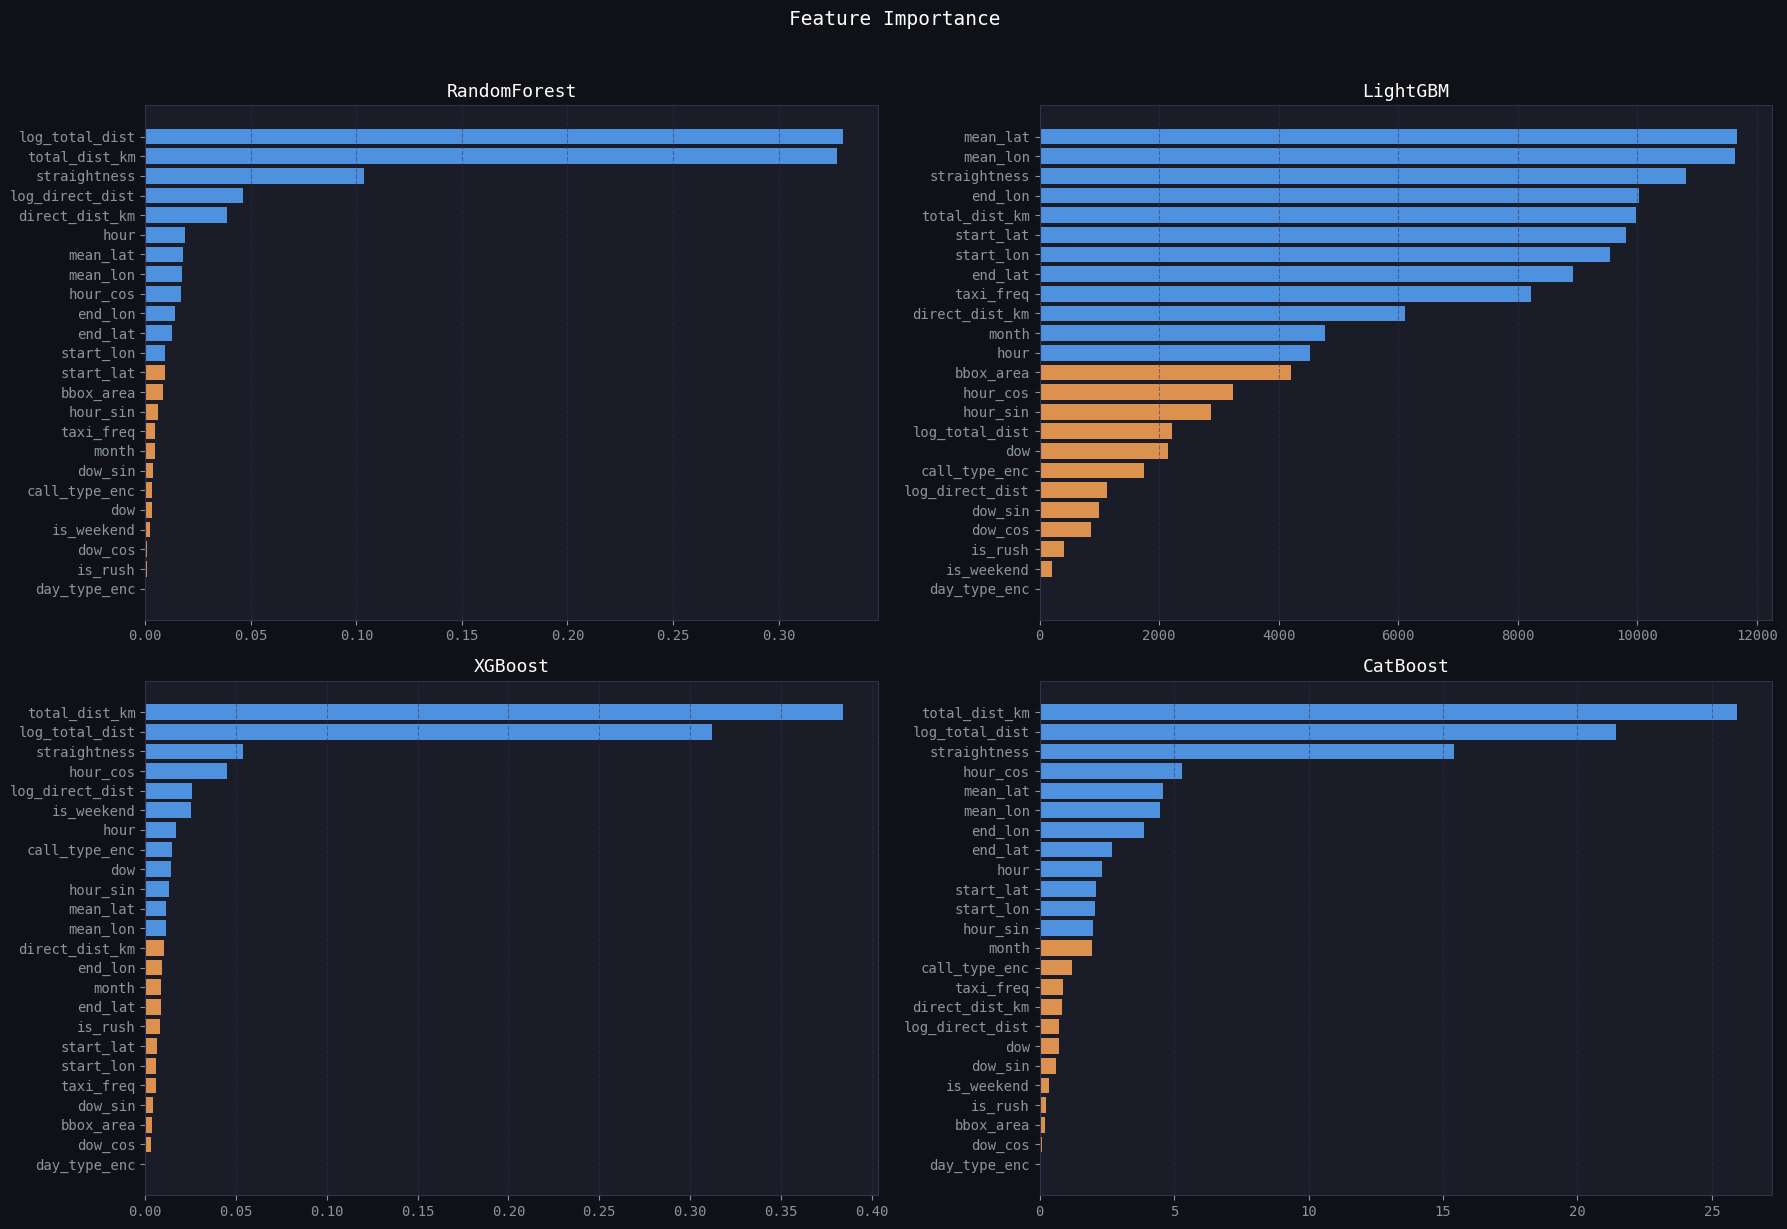

In [13]:
# Визуализация: Feature Importance

importance_models = {k: v for k, v in models.items()
                     if hasattr(v, 'feature_importances_') and k != 'Dummy'}

n = len(importance_models)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
if n == 1:
    axes = [axes]
axes = axes.flatten()    
fig.suptitle('Feature Importance', fontsize=14, color='white', y=1.02)

for i, (name, model) in enumerate(importance_models.items()):
    ax = axes[i]
    fi = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
    colors = [PALETTE[0] if v > fi.median() else PALETTE[4] for v in fi.values]
    ax.barh(fi.index, fi.values, color=colors, alpha=0.85)
    ax.set_title(name)
    ax.grid(True, axis='x')
    ax.set_facecolor('#1a1d27')

plt.tight_layout()
plt.show()

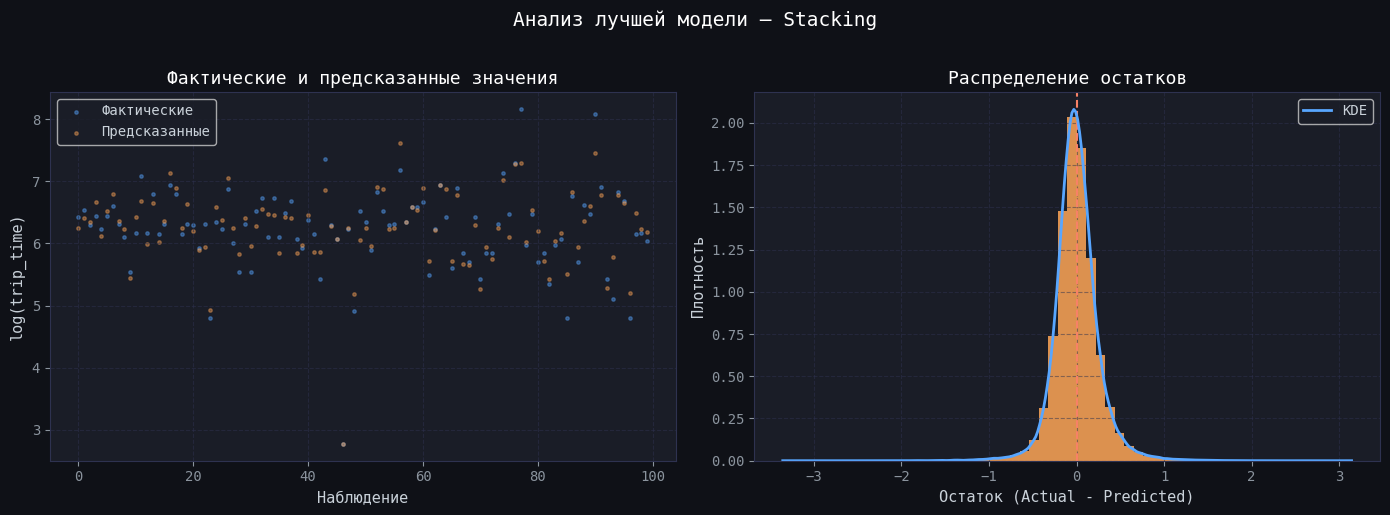

In [25]:
# Визуализация: Распределение ошибок (лучшая модель)

best_name = test_summary.loc[test_summary['RMSLE'].idxmin(), 'model']
best_pred = plot_preds[best_name]

# сэмпл для scatter
idx = np.random.choice(len(y_test), min(100, len(y_test)), replace=False)
yt  = np.array(y_test)[idx]
yp  = best_pred[idx]

residuals = np.array(y_test) - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Анализ лучшей модели — {best_name}', fontsize=14, color='white', y=1.02)

# Фактические vs предсказанные
axes[0].scatter(range(len(yt)), yt, color=PALETTE[0], alpha=0.4, s=6, label='Фактические')
axes[0].scatter(range(len(yp)), yp, color=PALETTE[4], alpha=0.4, s=6, label='Предсказанные')
axes[0].set_xlabel('Наблюдение')
axes[0].set_ylabel('log(trip_time)')
axes[0].set_title('Фактические и предсказанные значения')
axes[0].legend()
axes[0].grid(True)

# Распределение остатков
axes[1].hist(residuals, bins=60, color=PALETTE[4], alpha=0.85, edgecolor='none', density=True)
axes[1].axvline(0, color=PALETTE[1], linewidth=1.5, linestyle='--')
x_range = np.linspace(residuals.min(), residuals.max(), 300)
kde = gaussian_kde(residuals)
axes[1].plot(x_range, kde(x_range), color=PALETTE[0], linewidth=2, label='KDE')
axes[1].legend()
axes[1].set_title('Распределение остатков')
axes[1].set_xlabel('Остаток (Actual - Predicted)')
axes[1].set_ylabel('Плотность')
axes[1].grid(True)

for ax in axes:
    ax.set_facecolor('#1a1d27')

plt.tight_layout()
plt.show()

In [5]:
def objective_lgbm(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 500, 3000),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves":       trial.suggest_int("num_leaves", 31, 255),
        "max_depth":        trial.suggest_int("max_depth", 4, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 1.0, log=True),
        "n_jobs": -1, "random_state": 42, "verbose": -1,
    }
    model = lgb.LGBMRegressor(**params)
    oof   = cross_validate_model("LightGBM", model, X_train, y_train)
    return rmsle(y_train, oof)   # минимизируем RMSLE на OOF

study = optuna.create_study(direction="minimize")
study.optimize(objective_lgbm, n_trials=10)

print("Лучшие параметры:", study.best_params)
print("Лучший RMSLE:", study.best_value)

[I 2026-03-12 22:36:48,205] A new study created in memory with name: no-name-94c09e1e-4565-40ba-b41a-52089ee9002c


[I 2026-03-12 22:38:11,237] Trial 0 finished with value: 0.27420636679895816 and parameters: {'n_estimators': 882, 'learning_rate': 0.03822980142523011, 'num_leaves': 228, 'max_depth': 6, 'min_child_samples': 20, 'feature_fraction': 0.8358302757153212, 'bagging_fraction': 0.7954804951561265, 'reg_alpha': 0.007022669541447612, 'reg_lambda': 0.036964443698169494}. Best is trial 0 with value: 0.27420636679895816.


[I 2026-03-12 22:41:00,492] Trial 1 finished with value: 0.25852825667018664 and parameters: {'n_estimators': 2013, 'learning_rate': 0.09722465291028072, 'num_leaves': 127, 'max_depth': 6, 'min_child_samples': 35, 'feature_fraction': 0.6864518609344822, 'bagging_fraction': 0.8464980111025723, 'reg_alpha': 0.0025323850275862717, 'reg_lambda': 0.7322898754228114}. Best is trial 1 with value: 0.25852825667018664.


[I 2026-03-12 22:44:57,550] Trial 2 finished with value: 0.25814826906804095 and parameters: {'n_estimators': 1697, 'learning_rate': 0.028600332636825505, 'num_leaves': 195, 'max_depth': 9, 'min_child_samples': 19, 'feature_fraction': 0.5957670255247505, 'bagging_fraction': 0.6190547492520047, 'reg_alpha': 0.031668247702532085, 'reg_lambda': 0.006305007724562162}. Best is trial 2 with value: 0.25814826906804095.


[I 2026-03-12 22:47:30,075] Trial 3 finished with value: 0.2558308045193698 and parameters: {'n_estimators': 1220, 'learning_rate': 0.05477303975979096, 'num_leaves': 175, 'max_depth': 10, 'min_child_samples': 27, 'feature_fraction': 0.8823098534137493, 'bagging_fraction': 0.8430354755988337, 'reg_alpha': 0.0014943261437085523, 'reg_lambda': 0.0015301101665835763}. Best is trial 3 with value: 0.2558308045193698.


...

[I 2026-03-12 22:57:04,943] Trial 6 finished with value: 0.2674392265774984 and parameters: {'n_estimators': 1671, 'learning_rate': 0.017441596882756236, 'num_leaves': 93, 'max_depth': 12, 'min_child_samples': 14, 'feature_fraction': 0.6470275802005387, 'bagging_fraction': 0.9421661804368169, 'reg_alpha': 0.0651100432919631, 'reg_lambda': 0.1911225309145303}. Best is trial 3 with value: 0.2558308045193698.


[I 2026-03-12 23:00:13,415] Trial 7 finished with value: 0.25994733037307116 and parameters: {'n_estimators': 1371, 'learning_rate': 0.035797760105605446, 'num_leaves': 247, 'max_depth': 8, 'min_child_samples': 18, 'feature_fraction': 0.6087519022846158, 'bagging_fraction': 0.6477614860099161, 'reg_alpha': 0.5182141460094386, 'reg_lambda': 0.5966474170938465}. Best is trial 3 with value: 0.2558308045193698.


[I 2026-03-12 23:04:33,809] Trial 8 finished with value: 0.26477852427738313 and parameters: {'n_estimators': 2724, 'learning_rate': 0.017521428254617246, 'num_leaves': 79, 'max_depth': 12, 'min_child_samples': 12, 'feature_fraction': 0.547879473052973, 'bagging_fraction': 0.8150746307593186, 'reg_alpha': 0.0014019645209704138, 'reg_lambda': 0.3786414505879666}. Best is trial 3 with value: 0.2558308045193698.


[I 2026-03-12 23:06:56,094] Trial 9 finished with value: 0.28367601358254046 and parameters: {'n_estimators': 1625, 'learning_rate': 0.013034134196993586, 'num_leaves': 36, 'max_depth': 6, 'min_child_samples': 25, 'feature_fraction': 0.6070652821992, 'bagging_fraction': 0.9827571484525209, 'reg_alpha': 0.41677162130604317, 'reg_lambda': 0.4312975786261315}. Best is trial 3 with value: 0.2558308045193698.


Лучшие параметры: {'n_estimators': 1220, 'learning_rate': 0.05477303975979096, 'num_leaves': 175, 'max_depth': 10, 'min_child_samples': 27, 'feature_fraction': 0.8823098534137493, 'bagging_fraction': 0.8430354755988337, 'reg_alpha': 0.0014943261437085523, 'reg_lambda': 0.0015301101665835763}
Лучший RMSLE: 0.2558308045193698


In [6]:
best_params = study.best_params

best_params.update({
    "n_jobs":       -1,
    "random_state": RANDOM_STATE,
    "verbose":      -1,
})

# Переобучаем модель с лучшими параметрами
best_lgbm = lgb.LGBMRegressor(**best_params)

oof_lgbm  = cross_validate_model("LightGBM", best_lgbm, X_train, y_train)
best_lgbm.fit(X_train, y_train)
y_pred_lgbm = best_lgbm.predict(X_test)

evaluate("LightGBM (tuned) CV-OOF", y_train, oof_lgbm)
evaluate("LightGBM (tuned) TEST",   y_test,  y_pred_lgbm)

  [LightGBM (tuned) CV-OOF]  RMSLE=0.2558  MAE=134.1s  R²=0.8550
  [LightGBM (tuned) TEST]  RMSLE=0.2534  MAE=132.5s  R²=0.8569


{'model': 'LightGBM (tuned) TEST',
 'RMSLE': np.float64(0.2534408499125171),
 'MAE_sec': 132.54776675441343,
 'R2': 0.8568597644448389}

In [9]:
oof_dict["LightGBM"]       = oof_lgbm
test_pred_dict["LightGBM"] = y_pred_lgbm

y_pred_stack, meta_model = build_stacking_meta(
    oof_dict, y_train, test_pred_dict
)
results.append(evaluate('Stacking TEST', y_test, y_pred_stack))
print('\nВеса мета-модели (Ridge):')
stacking_names = [k for k in oof_dict if k != 'Dummy']
for name, coef in zip(stacking_names, meta_model.coef_):
    print(f'  {name:15s}: {coef:.4f}')

  [Stacking TEST]  RMSLE=0.2528  MAE=132.1s  R²=0.8575

Веса мета-модели (Ridge):
  RandomForest   : 0.0310
  LightGBM       : 1.0564
  XGBoost        : 0.1097
  CatBoost       : -0.1946


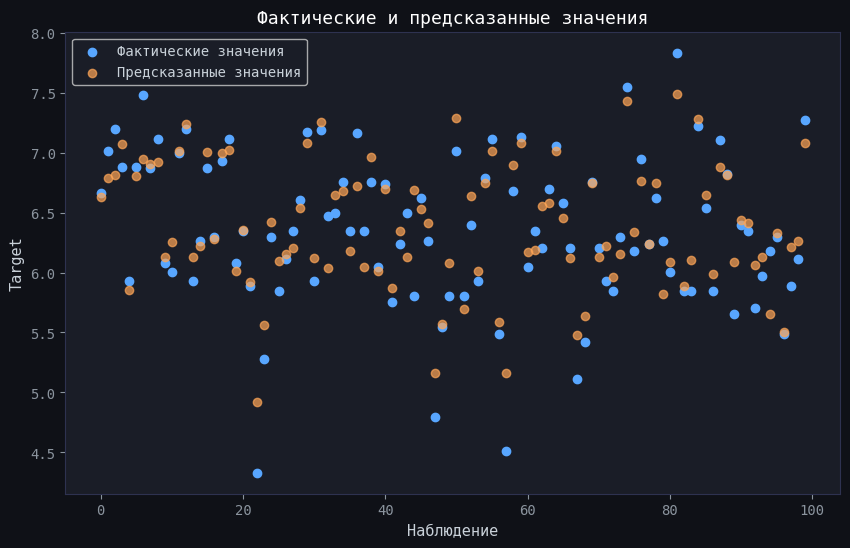

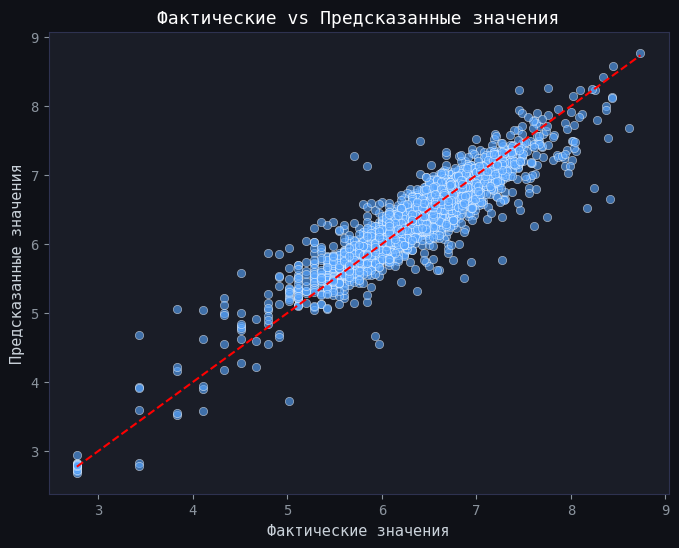

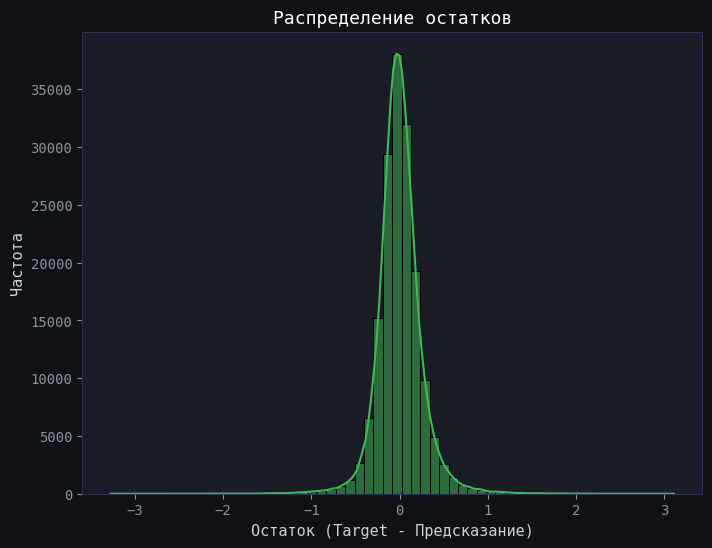

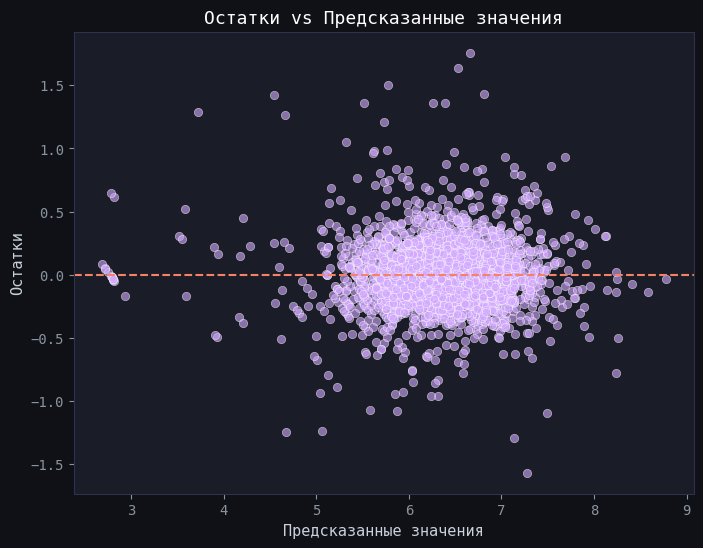

In [ ]:
# Визуализация предсказанных и фактических значений

summary = pd.DataFrame(results)
test_summary = summary[summary['model'].str.contains('TEST')].copy()
test_summary['model'] = test_summary['model'].str.replace(' TEST', '')
plot_preds = {**test_pred_dict, 'Stacking': y_pred_stack}
best_name = test_summary.loc[test_summary['RMSLE'].idxmin(), 'model']
best_pred = plot_preds[best_name]
idx = np.random.choice(len(y_test), min(100, len(y_test)), replace=False)
yt  = np.array(y_test)[idx]
yp  = best_pred[idx]
plt.figure(figsize=(10, 6))
plt.scatter(range(len(yt)), yt, color=PALETTE[0], label='Фактические значения')
plt.scatter(range(len(yp)), yp, color=PALETTE[4], label='Предсказанные значения', alpha=0.7)
plt.xlabel('Наблюдение')
plt.ylabel('Target')
plt.title('Фактические и предсказанные значения')
plt.legend()
plt.show()

# Диаграмма предсказанных vs фактических значений

idx = np.random.choice(len(y_test), min(3000, len(y_test)), replace=False)
yt  = np.array(y_test)[idx]
yp  = best_pred[idx]
plt.figure(figsize=(8, 6))
sns.scatterplot(x=yt, y=yp, color=PALETTE[0], alpha=0.6)
plt.plot([yt.min(), yt.max()], [yt.min(), yt.max()], 'r--')
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Фактические vs Предсказанные значения')
plt.show()

# График остатков

residuals = y_test - y_pred_stack
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=60, color=PALETTE[2])
plt.title('Распределение остатков')
plt.xlabel('Остаток (Target - Предсказание)')
plt.ylabel('Частота')
plt.show()

# Остатки vs Предсказанные значения

residuals = yt - yp
plt.figure(figsize=(8, 6))
sns.scatterplot(x=yp, y=residuals, color=PALETTE[3], alpha=0.6)
plt.axhline(0, color=PALETTE[1], linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('Остатки vs Предсказанные значения')
plt.show()

In [34]:
rows = []
for name, y_pred in plot_preds.items():
    rmsl = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(np.expm1(np.array(y_test)), np.expm1(y_pred))
    r2   = r2_score(y_test, y_pred)
    rows.append({'model': name, 'RMSLE': rmsl, 'MAE_sec': mae, 'R2': r2})

test_summary = pd.DataFrame(rows).sort_values('RMSLE').reset_index(drop=True)

best_row  = test_summary.iloc[0]
best_name = best_row['model']

print("=" * 50)
print("         ИТОГОВЫЙ ВЫВОД")
print("=" * 50)
print(f"  Лучшая модель : {best_name}")
print(f"  RMSLE         : {best_row['RMSLE']:.4f}")
print(f"  MAE           : {best_row['MAE_sec']:.1f} сек ({best_row['MAE_sec']/60:.1f} мин)")
print(f"  R²            : {best_row['R2']:.4f}")
print("=" * 50)

dummy_row   = test_summary.loc[test_summary['model'] == 'Dummy'].iloc[0]
improvement = (dummy_row['RMSLE'] - best_row['RMSLE']) / dummy_row['RMSLE'] * 100
print(f"  Улучшение vs Dummy : {improvement:.1f}% по RMSLE")
print("=" * 50)

print("\nВсе модели (по RMSLE):")
print(test_summary[['model','RMSLE','MAE_sec','R2']].to_string(index=False))

         ИТОГОВЫЙ ВЫВОД
  Лучшая модель : Stacking
  RMSLE         : 0.2528
  MAE           : 132.1 сек (2.2 мин)
  R²            : 0.8575
  Улучшение vs Dummy : 62.3% по RMSLE

Все модели (по RMSLE):
           model    RMSLE    MAE_sec        R2
        Stacking 0.252834 132.087097  0.857544
LightGBM (tuned) 0.253441 132.547767  0.856860
         XGBoost 0.263235 137.529563  0.845583
        CatBoost 0.280856 148.357082  0.824217
    RandomForest 0.281140 146.032535  0.823862
           Dummy 0.669878 322.256277 -0.000001
